# **Leveraging Machine Learning to Predict Diabetes Using Patient-Level Health and Risk Factors:** Insights from the *Diabetes Helath Indicators* Dataset

(replace with Final Title)

**Team:** Esther Toobian, Edwin Mutimba  
**Course:** STAT 587: Data Science I  (Winter 2026 )

## Research Questions

**Primary:** 

How do supervised learning modeling approaches compare in predictive performance and interpretability for diabetes diagnosis?  

**Secondary:**  
1. Which patient-level health and risk factors are most influential across models? 
2. What is the incremental predictive contribution of the diagnostic variable `HbA1c`?

## Notebook Purpose

This notebook is the **single, fully reproducible** analysis pipeline for the project. Run top-to-bottom to reproduce:
- processed data written to `data/processed/`
- figures written to `results/figures/`
- tables written to `results/tables/`
- model comparisons and test-set evaluation

All reusable logic lives in `src/` to keep this notebook focused on an auditable pipeline.

---

## **0.** Setup

This section initializes the environment and establishes global settings used throughout the notebook.

- The repository has the following directories:
  - `data/raw/` — raw input dataset(s)
  - `data/processed/` — generated, reproducible processed data
  - `results/figures/` — saved plots
  - `results/tables/` — saved tables and summaries
- All randomness is controlled via a single global seed.

In [ ]:
# SET PROJECT ROOT

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
assert (
    PROJECT_ROOT / "src"
).exists(), "Run this notebook from notebooks/ (or adjust PROJECT_ROOT)."
sys.path.insert(0, str(PROJECT_ROOT))

# Ensure output directories exist
from src.paths import ensure_dirs, PROC_SPLITS_DIR, PROC_CURATED_DIR, PROC_REDUCED_DIR, FIG_DIR, TAB_DIR

ensure_dirs()

# Project modules (to be implemented)
import src
sch = src.schema
io  = src.io
pp  = src.preprocessing
viz = src.viz
mdl = src.modeling
mtx = src.metrics

In [ ]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import math
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [ ]:
# SET SEED 

SEED = 587
np.random.seed(SEED)

In [ ]:
#  GLOBAL PARAMETER CONTROLS

viz.set_plot_defaults()

In [ ]:
# GLOBAL OUTPUT CONTROLS

VERBOSE = True  # print / display intermediate outputs
SAVE_FIGS = True  # write figures to results/figures/
SAVE_TABLES = True  # write tables to results/tables/

---

## **1.** Data Description and Loading

This section introduces the dataset and performs initial structural validation, including inspection of dimensions, variable types, missing values, and duplicate records.

**Dataset:** Diabetes Health Indicator Dataset (synthetic population-level health records).
**Size:** 100,000 observations, 31 variables.  
**Outcome:** Binary diabetes diagnosis (0 = No, 1 = Yes).  
**Predictors:** Demographics, lifestyle, medical history, clinical measurements, derived risk measures.

**Note:** Dataset documentation may not perfectly match the CSV; the CSV is treated as the authoritative source.

In [ ]:
# Load data
df_raw = io.load_raw_diabetes()

if VERBOSE:
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)

    n_rows, n_cols = df_raw.shape
    print(f"Observations: {n_rows:,}")
    print(f"Variables:    {n_cols}")

    print("\nCOLUMN NAMES:")
    print(", ".join(df_raw.columns))

    print("\nDATA TYPES:")
    dtype_df = df_raw.dtypes.to_frame(name="dtype")
    print(dtype_df)

    print("\nMISSING VALUES (nonzero only):")
    mv = df_raw.isna().sum()
    mv_nonzero = mv[mv > 0]
    if mv_nonzero.empty:
        print("None")
    else:
        print(mv_nonzero)

    dup_count = df_raw.duplicated().sum()
    print(f"\nDuplicate rows: {dup_count}")

    print("=" * 60)


DATASET OVERVIEW
Observations: 100,000
Variables:    31

COLUMN NAMES:
age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes

DATA TYPES:
                                      dtype
age                                   int64
gender                               object
ethnicity                            object
education_level                      object
income_level                         object
employment_status                    object
smoking_status                       object
alcohol_consumption_per_week

### Summary

The dataset contains **100,000 observations** and **31 variables**.  
**No missing values or duplicate rows** were detected.  

All variables were successfully loaded with consistent data types.  
Further validation of variable types and value ranges will be conducted in the preprocessing stage.

---

## **2.** Base Split and Preprocessing

This section establishes the **reproducible modeling foundation** for the project and performs structured data validation.

Because no missing values or duplicate rows were detected in *Section 1*, preprocessing focuses on:
- Enforcing expected data types and domains (e.g., binary indicators, categorical variables)
- Verifying plausible value ranges for clinical and demographic variables
- Identifying potential leakage variables for downstream modeling decisions

- Leakage removal prior to splitting
- Stratified train/test split
- Standardization of variable types
- Train-only data validation audits

The following pipeline is enforced:

1. **Leakage removal**
   - Drop `diabetes_stage` and `diabetes_risk_score`
   - These variables encode post-diagnosis information or composite risk measures and would introduce target leakage.

2. **Stratified train/test split**
   - Stratified on `diagnosed_diabetes`
   - Controlled by a fixed global seed
   - Preserves class distribution across splits

3. **Type coercion**
   - Standardize categorical, numeric, and binary types
   - No feature engineering performed at this stage

4. **Train-only validation audits**
   - Binary domain checks
   - Categorical level audits
   - Numeric range validation using:
     - **Reference bounds** (dataset card / Kaggle documentation) for reporting
     - **Operational sanity bounds** reflecting the dataset actually used

The CSV is treated as authoritative. When documentation and observed data disagree, we:
- report discrepancies via reference audits, and
- define operational expectations for modeling consistent with observed data.

All reusable logic is implemented in `src/preprocessing.py`.
Checkpoint datasets are saved to `data/processed/`.

### **2.1** Leakage Variable Drop and Stratified Split

In [ ]:
# BASE SPLIT
train_base_raw, test_base_raw = pp.make_base_split(
    df_raw,
    seed=SEED,
    test_size=0.2,
)

# Apply dtype coercion
train_base = pp.coerce_types(train_base_raw)
test_base = pp.coerce_types(test_base_raw)

# Save base datasets
io.save_processed_data(train_base, PROC_SPLITS_DIR / "train_base.csv")
io.save_processed_data(test_base, PROC_SPLITS_DIR / "test_base.csv")

# Save split metadata
io.save_metadata_json(
    {
        "target": sch.TARGET_COL,
        "leakage_cols": sch.LEAKAGE_COLS,
        "seed": SEED,
        "test_size": 0.2,
        "train_rows": int(train_base.shape[0]),
        "test_rows": int(test_base.shape[0]),
        "train_class_counts": train_base[sch.TARGET_COL].value_counts().to_dict(),
        "test_class_counts": test_base[sch.TARGET_COL].value_counts().to_dict(),
    },
    PROC_SPLITS_DIR / "split.json",
)

if VERBOSE:
    print("Train shape:", train_base.shape)
    print("Test shape: ", test_base.shape)

Train shape: (80000, 29)
Test shape:  (20000, 29)


### **2.2** Validation on Training Set

In [ ]:
# Binary domain (must be {0,1})
bin_viol = pp.check_binary_domains(train_base)

if VERBOSE:
    print("Binary domain violations:", bin_viol if bin_viol else "None")

Binary domain violations: None


In [ ]:
# Categorical audit vs Kaggle reference
cat_ref = pp.check_allowed_categories(train_base, reference=True)

if VERBOSE:
    print("\nCategorical deviations vs Kaggle reference (train audit):")
    print(cat_ref if cat_ref else "None")

    # Print all columns with missing/extra levels vs Kaggle reference
    pp.print_categorical_audit(train_base)


Categorical deviations vs Kaggle reference (train audit):
{'income_level': ['Lower-Middle', 'Middle', 'Upper-Middle']}

------------------------------------------------------------
income_level
------------------------------------------------------------
Observed: ['High', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle']
Expected (REF): ['Low', 'Medium', 'High']
Missing expected: ['Medium']
Extra/unexpected: ['Lower-Middle', 'Middle', 'Upper-Middle']


In [ ]:
# Numeric range audit vs Kaggle reference
rng_ref = pp.check_numeric_ranges(train_base, reference=True)

if VERBOSE:
    print("\nNumeric deviations vs Kaggle reference (train audit):")
    # Show columns with nonzero deviations vs Kaggle reference
    display(rng_ref if not rng_ref.empty else pd.DataFrame())


Numeric deviations vs Kaggle reference (train audit):


,feature,min_allowed,max_allowed,data_min,data_max,below_min,above_max,pct_outside
0,triglycerides,50.0,500.0,30.00,344.00,4196,0,0.052450
1,diastolic_bp,60.0,120.0,50.00,110.00,2237,0,0.027963
2,cholesterol_total,120.0,300.0,100.00,318.00,1585,14,0.019987
3,glucose_postprandial,90.0,350.0,70.00,287.00,916,0,0.011450
4,heart_rate,50.0,120.0,40.00,105.00,647,0,0.008087
5,screen_time_hours_per_day,0.0,12.0,0.50,16.80,0,617,0.007712
6,ldl_cholesterol,50.0,200.0,50.00,263.00,0,228,0.002850
7,glucose_fasting,70.0,250.0,60.00,172.00,80,0,0.001000
8,physical_activity_minutes_per_week,0.0,600.0,0.00,833.00,0,37,0.000463
9,waist_to_hip_ratio,0.7,1.2,0.67,1.05,17,0,0.000212


In [ ]:
# Check against new Operational sanity bounds
rng_op = pp.check_numeric_ranges(train_base, reference=False)

if VERBOSE:
    print("\nOperational sanity range validation (train guardrail):")
    if rng_op.empty:
        print("No operational range violations detected.")
    else:
        print("Operational range violations detected:")
        display(rng_op)


Operational sanity range validation (train guardrail):
No operational range violations detected.


### Summary

The following steps were performed:

- **Leakage removal prior to splitting**
  - `diabetes_stage`: Post-diagnosis categorization that directly encodes disease status; retaining it would result in target leakage.
  - `diabetes_risk_score`: Composite risk index derived from predictor variables using unknown methodology; effectively an alternative target and not an independent feature.

- **Stratified train/test split**
  - 80\% Train / 20 \% Test
  - Controlled by global seed
  - Preserves class distribution

- **Standardized data types**
  - Categorical variables cast to `category`
  - Numeric variables coerced to numeric dtype
  - Binary indicators validated as integer (0/1)

- **Verified Data Integrity (Train Only)**
  - Binary domains restricted to {0, 1}
  - Categorical levels audited (documentation vs. observed; CSV treated as authoritative)
  - Numeric variables checked against both reference ranges (documentation audit) and operational guardrails (realistic clinical bounds). No operational guardrail violations were detected.

The base datasets have been saved and will serve as the foundation for all
subsequent modeling steps.

---

## **3.** Exploratory Data Analysis (EDA)

### EDA Introduction

This section explores the dataset to understand its structure, distributions, and key patterns before modeling. We examine the target variable, summarize numeric and categorical features, check relationships with the target, assess correlations, and investigate potential outliers.

**Status:** Pending. EDA figures/tables are maintained on a dedicated branch and will be merged here once finalized.

**Train-only policy:** All EDA related to feature selection and feature-curation decisions are performed using `train_base` only.  
`test_base` is not used for EDA and is reserved for final evaluation.

### EDA Plots/Tables/Figures/
(NOTES, I think you did more than this. These are just baseline ideas)

1) **Target distribution**
    - Class balance table and/or plot (train only)
2) **Feature summaries**
    - Numeric summary stats (mean/std/quantiles)
    - Categorical level counts
3) **Univariate distributions**
    - Histograms/boxplots for key numeric features
    - Bar charts for categorical features
4) **Relationship to target (train only)**
    - Grouped summaries (mean/median by target)
    - Selected plots showing separation
5) **Redundancy and correlation checks (train only)**
    - Correlation heatmap for numeric predictors
    - Notes on redundancy families (e.g., cholesterol, glucose, body composition)
6) **Outlier checks (train only)**
    - Identify any extreme values and whether they are retained under operational guardrails

Key figures should be saved to `results/figures/` and key tables to `results/tables/`.

In [ ]:
# Load base train/test splits (created in Section 2)
train_base = io.load_processed_data(PROC_SPLITS_DIR / "train_base.csv")
test_base = io.load_processed_data(PROC_SPLITS_DIR / "test_base.csv")

if VERBOSE:
    print("Loaded base splits:")
    print("  train_base:", train_base.shape)
    print("  test_base: ", test_base.shape)

    # quick class-balance sanity check (informational only)
    print("\nTrain class counts:")
    print(train_base[sch.TARGET_COL].value_counts().sort_index())

    print("\nTest class counts:")
    print(test_base[sch.TARGET_COL].value_counts().sort_index())

Loaded base splits:
  train_base: (80000, 29)
  test_base:  (20000, 29)

Train class counts:
diagnosed_diabetes
0    32002
1    47998
Name: count, dtype: int64

Test class counts:
diagnosed_diabetes
0     8000
1    12000
Name: count, dtype: int64


In [ ]:
# Ensure variables are of the Correct Data Type
df = pp.coerce_types(df_raw)

### **3.1** Target distribution and class balance

Target Distribution Summary (Full vs Train)


,Class Label,Full Count,Full Percentage (%),Train Count,Train Percentage (%)
0,No Diabetes,"40,002",40.00%,"32,002",40.00%
1,Diagnosed Diabetes,"59,998",60.00%,"47,998",60.00%



Imbalance Ratio (Full): 1.50
Imbalance Ratio (Train): 1.50


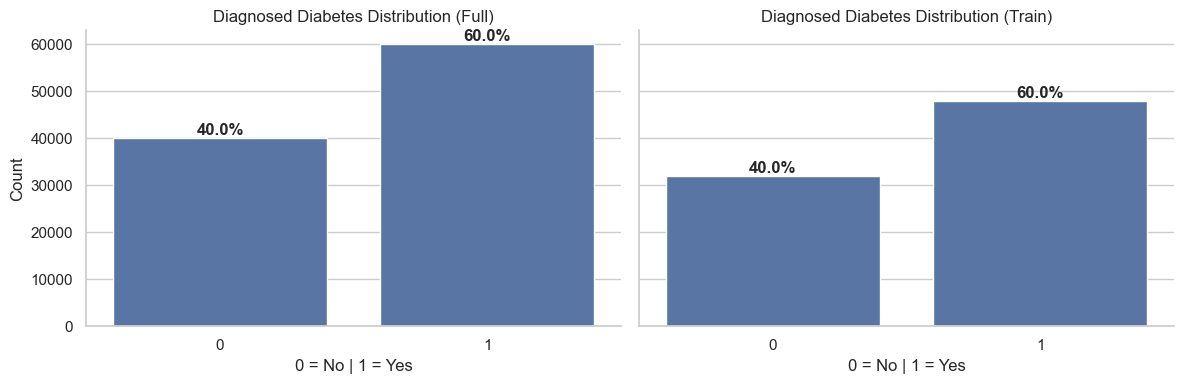

In [ ]:
# Compute class distribution (FULL)
class_counts = df[sch.TARGET_COL].value_counts().sort_index()
class_props = class_counts / class_counts.sum()

# Compute class distribution (TRAIN)
train_counts = train_base[sch.TARGET_COL].value_counts().sort_index()
train_props = train_counts / train_counts.sum()

# Create summary table
comparison_summary = pd.DataFrame({
    "Class Label": ["No Diabetes", "Diagnosed Diabetes"],
    "Full Count": class_counts.values,
    "Full Percentage (%)": class_props.values * 100,
    "Train Count": train_counts.values,
    "Train Percentage (%)": train_props.values * 100
})

print("Target Distribution Summary (Full vs Train)")

display(
    comparison_summary.style.format({
        "Full Count": "{:,}",
        "Train Count": "{:,}",
        "Full Percentage (%)": "{:.2f}%",
        "Train Percentage (%)": "{:.2f}%"
    })
)

comparison_summary.to_csv(
    TAB_DIR / "target_distribution_full_vs_train.csv",
    index=False
)

# Imbalance ratios
full_imbalance_ratio = class_props.max() / class_props.min()
train_imbalance_ratio = train_props.max() / train_props.min()

print(f"\nImbalance Ratio (Full): {full_imbalance_ratio:.2f}")
print(f"Imbalance Ratio (Train): {train_imbalance_ratio:.2f}")

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Full dataset plot
sns.barplot(
    x=class_counts.index.astype(str),
    y=class_counts.values,
    color="#4C72B0",
    ax=axes[0]
)

for i, p in enumerate(class_props.values):
    axes[0].text(
        i,
        class_counts.values[i],
        f"{p*100:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

axes[0].set_title("Diagnosed Diabetes Distribution (Full)")
axes[0].set_xlabel("0 = No | 1 = Yes")
axes[0].set_ylabel("Count")

# Train dataset plot
sns.barplot(
    x=train_counts.index.astype(str),
    y=train_counts.values,
    color="#4C72B0",
    ax=axes[1]
)

for i, p in enumerate(train_props.values):
    axes[1].text(
        i,
        train_counts.values[i],
        f"{p*100:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

axes[1].set_title("Diagnosed Diabetes Distribution (Train)")
axes[1].set_xlabel("0 = No | 1 = Yes")
axes[1].set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "target_distribution_full_vs_train.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.2 Summary statistics for numeric features

In [ ]:
# Select numeric features defined in the project schema
numeric_df = df[sch.NUMERIC_COLS]

# Generate summary statistics
numeric_summary = numeric_df.describe().T

# Add feature range
numeric_summary["range"] = numeric_summary["max"] - numeric_summary["min"]

# Optional: round for cleaner reporting
numeric_summary = numeric_summary.round(3)

# Display if verbose
if VERBOSE:
    print("Numeric Feature Summary Statistics:")
    display(numeric_summary)

# Save CSV
io.save_table_csv(
    numeric_summary,
    TAB_DIR / "numeric_summary_statistics.csv",
    save=SAVE_TABLES,
)

# Save LaTeX
io.save_table_tex(
    numeric_summary,
    TAB_DIR / "numeric_summary_statistics.tex",
    caption="Summary statistics for numeric features including mean, standard deviation, quartiles, and computed range.",
    label="tab:numeric_summary_statistics",
    save=SAVE_TABLES,
);

Numeric Feature Summary Statistics:


,count,mean,std,min,25%,50%,75%,max,range
age,100000.0,50.120,15.605,18.00,39.00,50.00,61.00,90.00,72.00
alcohol_consumption_per_week,100000.0,2.004,1.418,0.00,1.00,2.00,3.00,10.00,10.00
physical_activity_minutes_per_week,100000.0,118.912,84.410,0.00,57.00,100.00,160.00,833.00,833.00
diet_score,100000.0,5.995,1.781,0.00,4.80,6.00,7.20,10.00,10.00
sleep_hours_per_day,100000.0,6.998,1.095,3.00,6.30,7.00,7.70,10.00,7.00
screen_time_hours_per_day,100000.0,5.996,2.468,0.50,4.30,6.00,7.70,16.80,16.30
bmi,100000.0,25.613,3.587,15.00,23.20,25.60,28.00,39.20,24.20
waist_to_hip_ratio,100000.0,0.856,0.047,0.67,0.82,0.86,0.89,1.06,0.39
systolic_bp,100000.0,115.800,14.284,90.00,106.00,116.00,125.00,179.00,89.00
diastolic_bp,100000.0,75.232,8.204,50.00,70.00,75.00,81.00,110.00,60.00


### 3.3 Univariate distributions

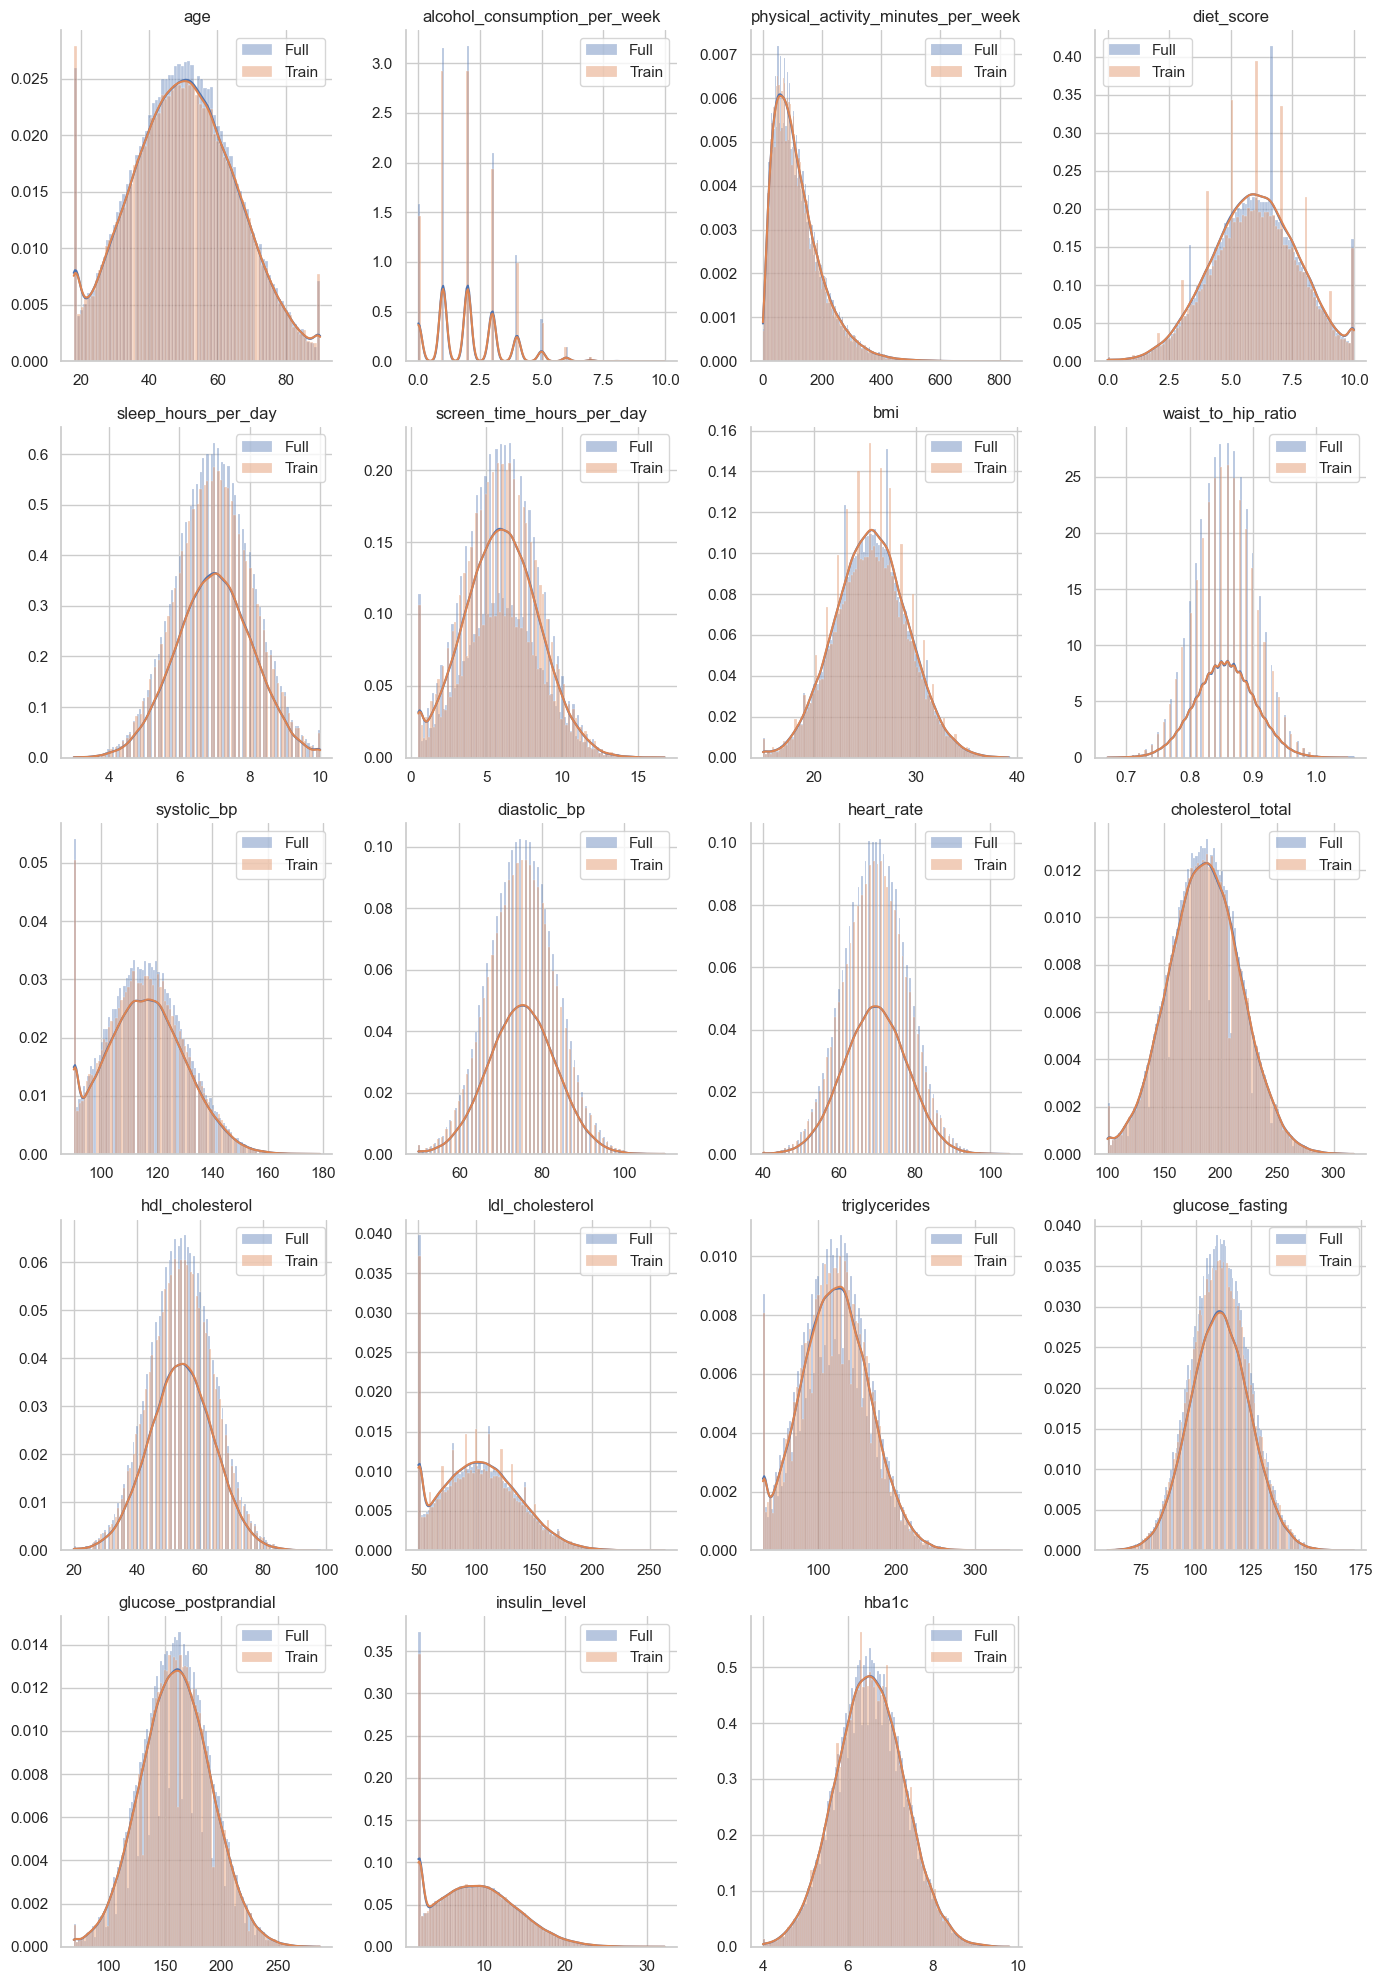

In [ ]:
# Use all numeric features from schema
numeric_cols = sch.NUMERIC_COLS
n_features = len(numeric_cols)

# Dynamically determine grid size (4 columns layout)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    
    # Full dataset (base layer)
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color="#4C72B0",
        stat="density",
        alpha=0.4,
        label="Full"
    )
    
    # Train dataset (overlay)
    sns.histplot(
        train_base[col],
        kde=True,
        ax=axes[i],
        color="#DD8452",
        stat="density",
        alpha=0.4,
        label="Train"
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].legend()

# Hide unused panels if grid > number of features
for j in range(n_features, len(axes)):
    axes[j].axis("off")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "univariate_distribution_grid_overlay_full_vs_train.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### 3.4 Categorical level distribution in relation to target

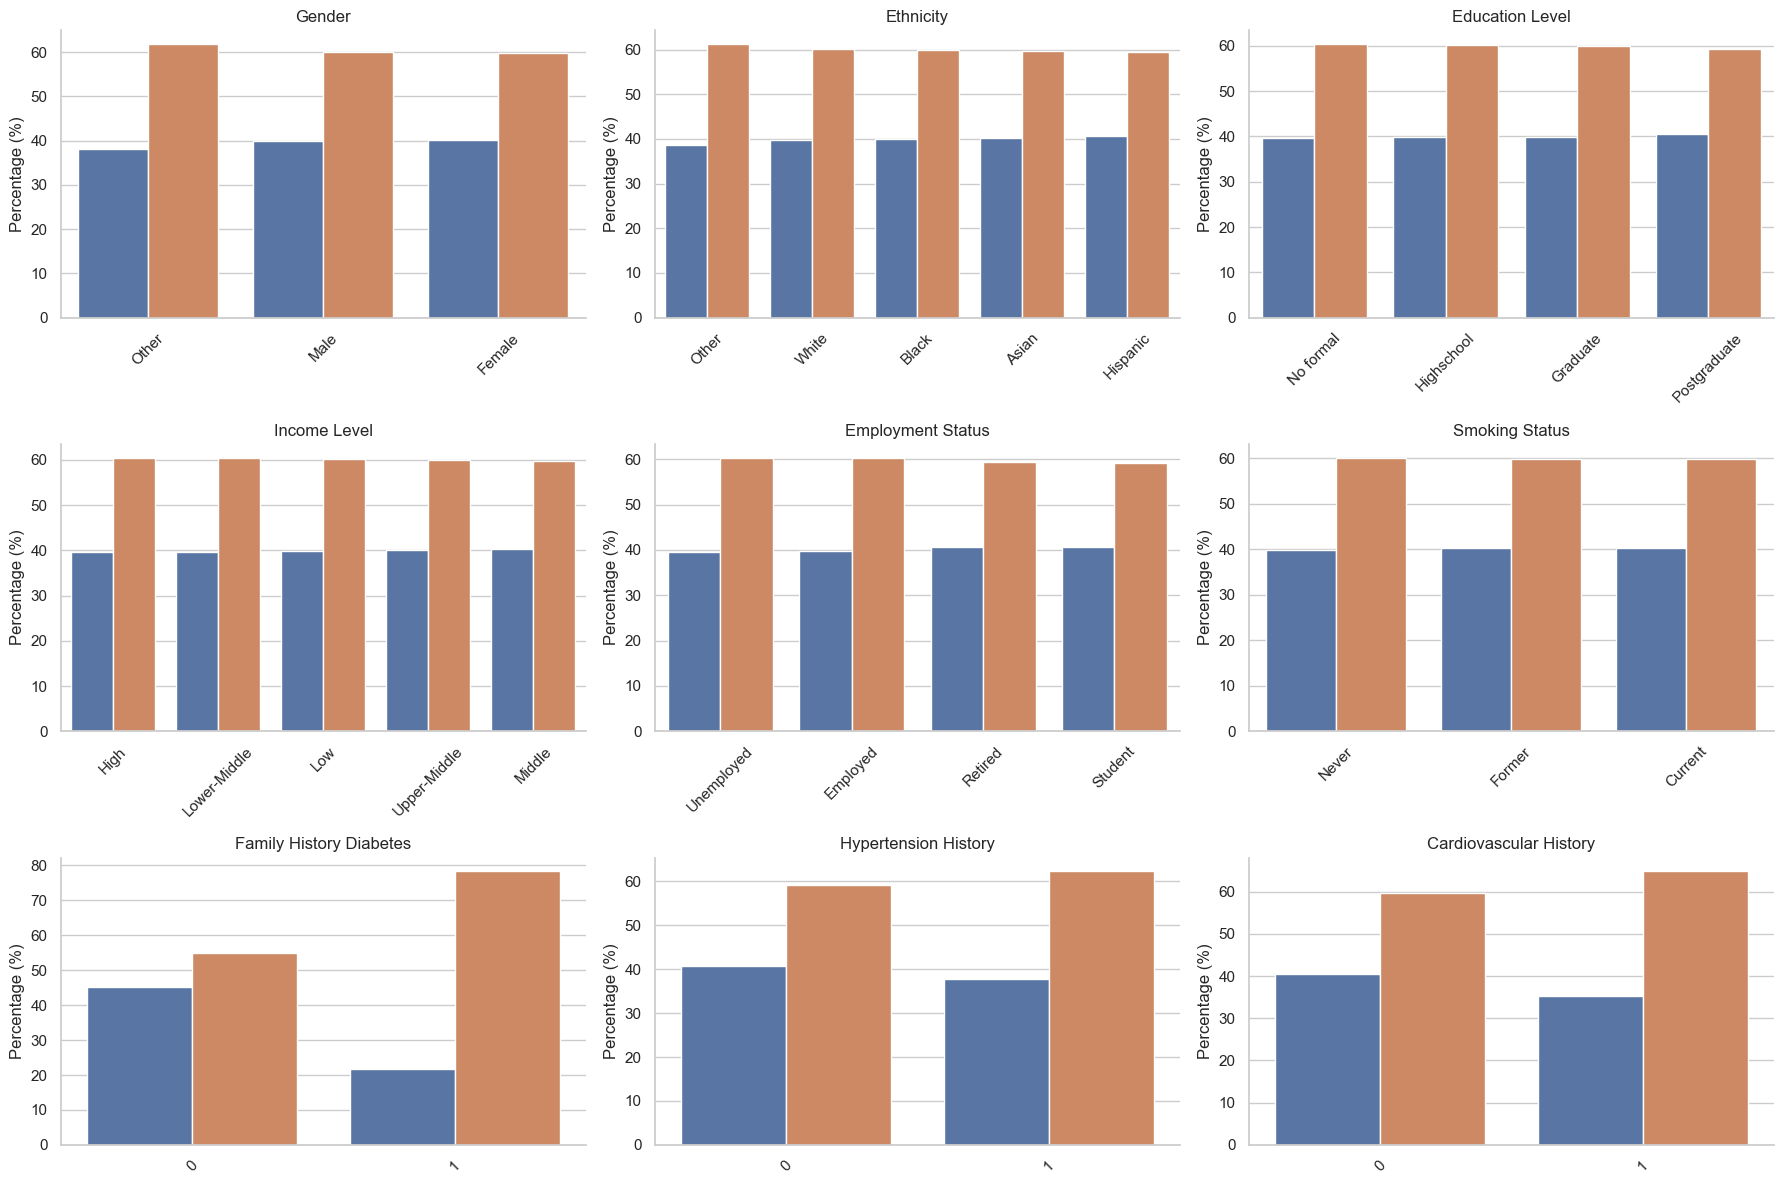

In [ ]:
all_cat_features = sch.ALL_CATEGORICAL
target = sch.TARGET_COL

n_features = len(all_cat_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_cat_features):

    ct = pd.crosstab(train_base[col], train_base[target], normalize="index") * 100

    # Ensure correct sorting (assuming 1 = Diabetes)
    if 1 in ct.columns:
        ct = ct.sort_values(by=1, ascending=False)

    ct_reset = ct.reset_index().melt(
        id_vars=col,
        var_name="Diabetes",
        value_name="Percentage"
    )

    sns.barplot(
        data=ct_reset,
        x=col,
        y="Percentage",
        hue="Diabetes",
        palette=["#4C72B0", "#DD8452"],
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=45)

    axes[i].legend_.remove()

# Hide unused panels
for j in range(n_features, len(axes)):
    axes[j].axis("off")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "categorical_binary_vs_target_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.5 Numeric vs Target Distribution

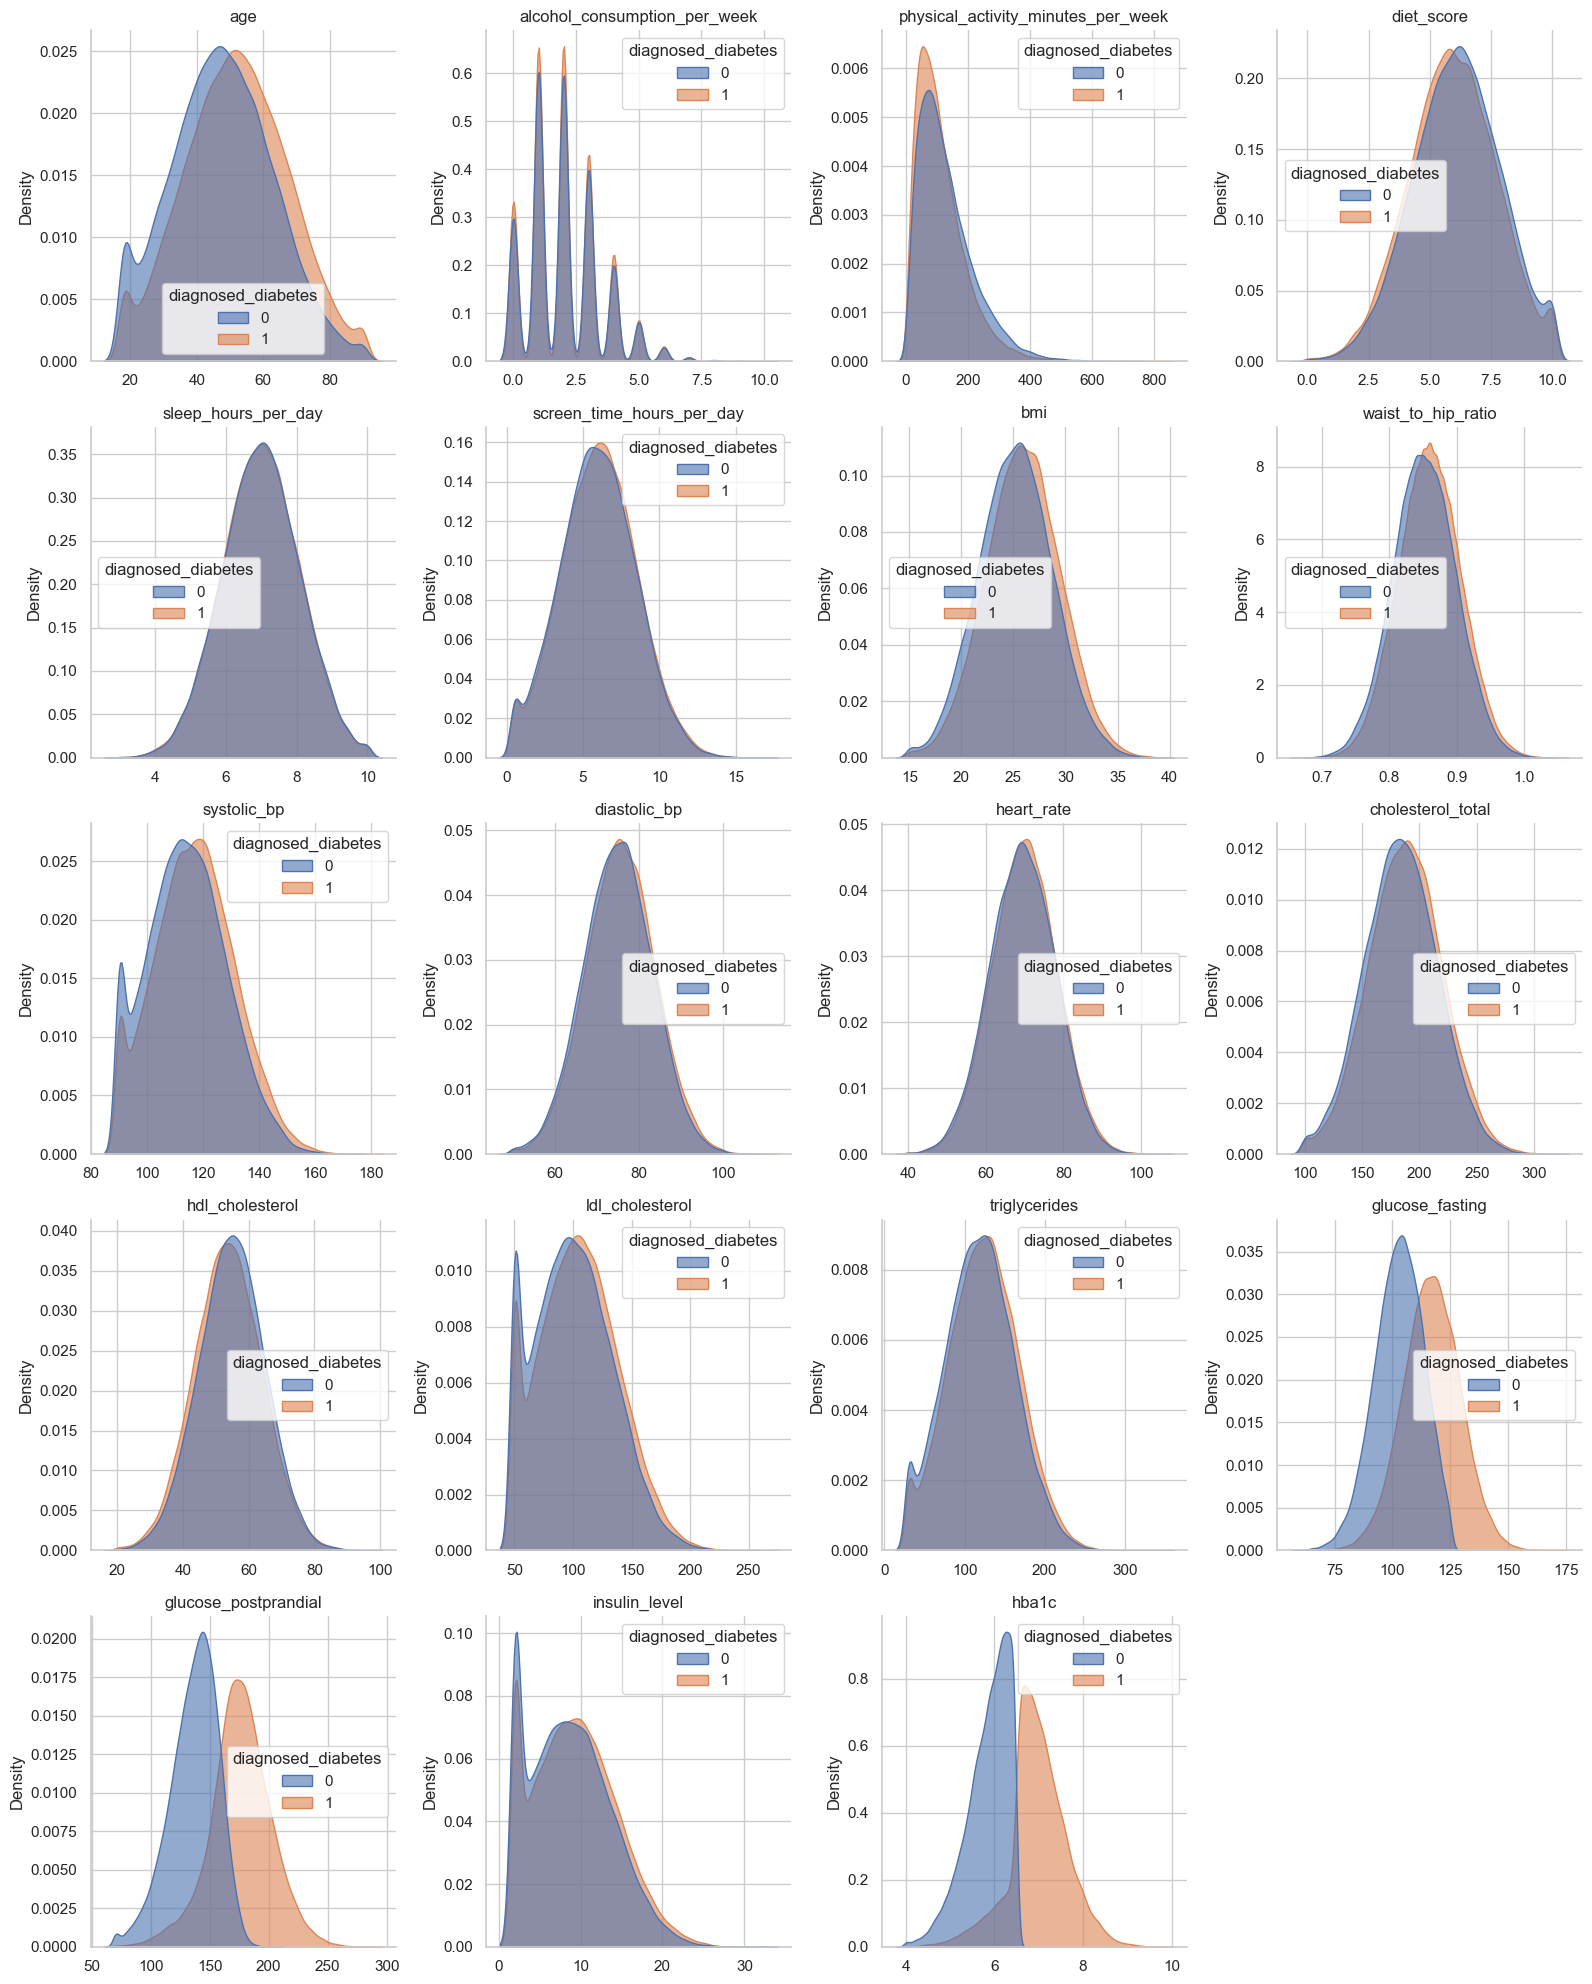

In [ ]:
n_features = len(numeric_cols)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.kdeplot(
        data=train_base,
        x=col,
        hue=target,
        fill=True,
        common_norm=False,
        palette=["#4C72B0", "#DD8452"],
        alpha=0.6,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Hide unused panels
for j in range(n_features, len(axes)):
    axes[j].axis("off")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "relationship_kde_grid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 3.6.1 Correlation Analysis

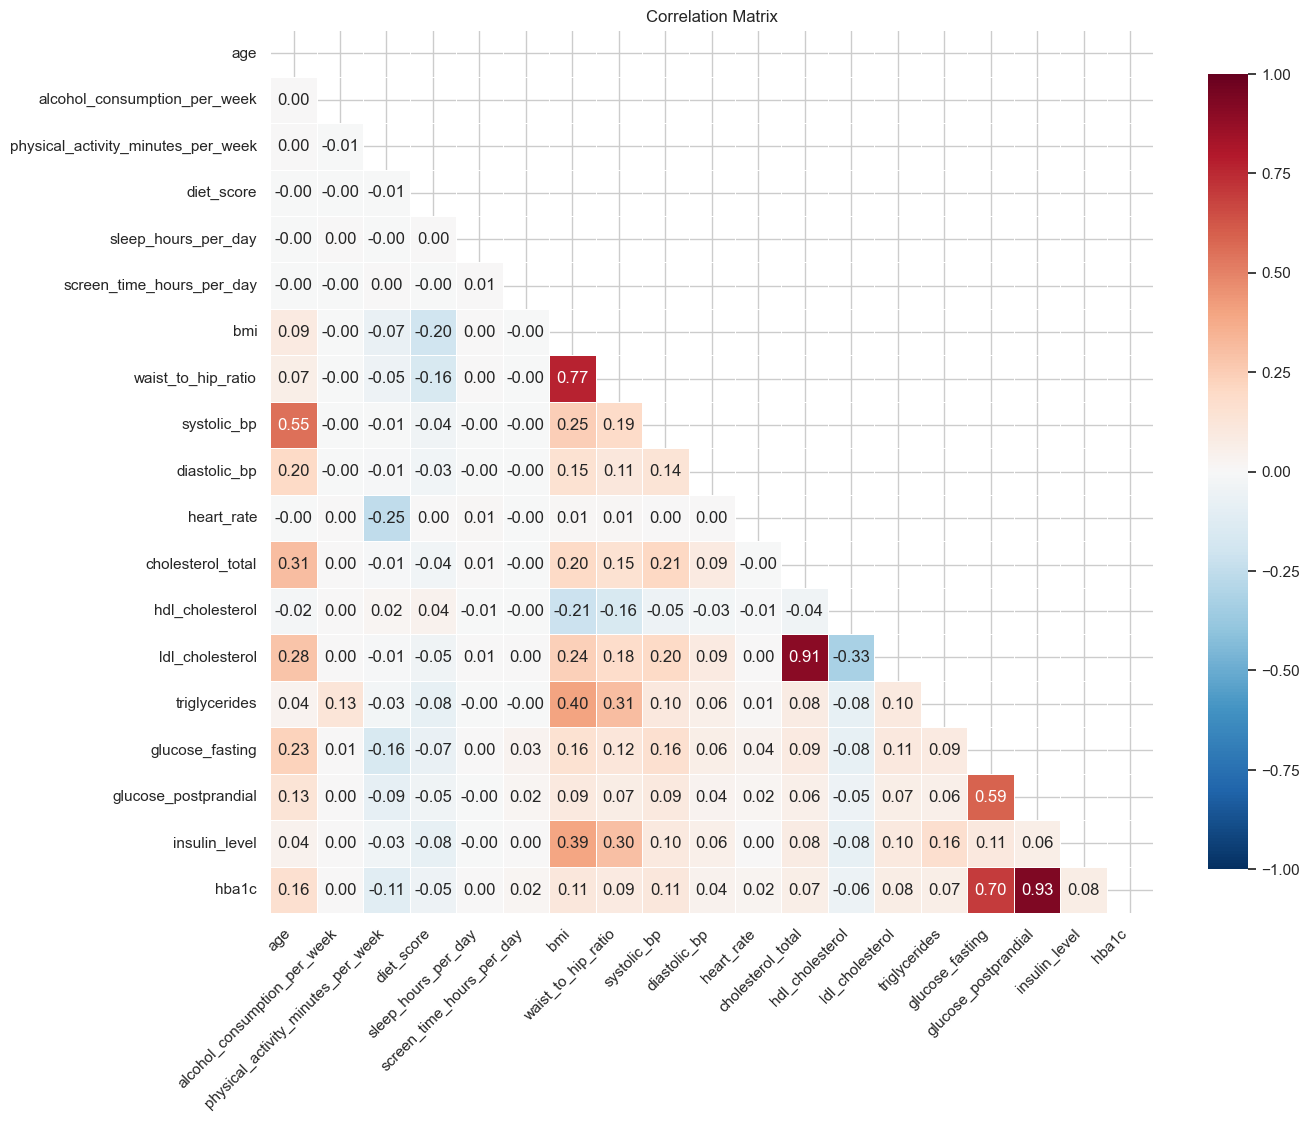

In [ ]:
# Compute correlation matrix
corr_matrix = train_base[sch.NUMERIC_COLS].corr()

# Mask upper triangle to remove duplication
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",          # stronger visual contrast
    center=0,
    vmin=-1, vmax=1,        # consistent color scale
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(FIG_DIR / "correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


### 3.6.2 Check for Variance Inflation Factor

In [ ]:
# Dummy encode categorical variables 
X_cat = pd.get_dummies(
    train_base[sch.ALL_CATEGORICAL],
    drop_first=True
)

# Remove redundant numeric variables
drop_vars = [
    "glucose_postprandial",
    "glucose_fasting",
    "cholesterol_total",
    "waist_to_hip_ratio"
]

numeric_vars = [
    col for col in sch.NUMERIC_COLS
    if col not in drop_vars
]

# Combine categorical + cleaned numeric
X_full = pd.concat([X_cat, train_base[numeric_vars]], axis=1)

# Add constant
X_full = sm.add_constant(X_full)

# Ensure numpy float array
X_values = X_full.values.astype(float)

# Compute VIF
vif_full = pd.DataFrame({
    "Variable": X_full.columns,
    "VIF": [
        variance_inflation_factor(X_values, i)
        for i in range(X_values.shape[1])
    ]
})

# Sort and round
vif_full = (
    vif_full
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_full["VIF"] = vif_full["VIF"].round(3)

# Display if verbose
if VERBOSE:
    print("Variance Inflation Factors (Train Data)")
    display(vif_full)

# Save CSV
io.save_table_csv(
    vif_full,
    TAB_DIR / "vif_train_full_model.csv",
    save=SAVE_TABLES,
)

# Save LaTeX
io.save_table_tex(
    vif_full,
    TAB_DIR / "vif_train_full_model.tex",
    caption="Variance Inflation Factors (VIF) computed on the training dataset after dummy encoding categorical variables and removing redundant numeric predictors.",
    label="tab:vif_train_full_model",
    escape_underscore_cols=("Variable",),
    save=SAVE_TABLES,
);

Variance Inflation Factors (Train Data)


,Variable,VIF
0,const,471.264
1,income_level_Middle,5.216
2,income_level_Lower-Middle,4.522
3,income_level_Upper-Middle,3.998
4,income_level_Low,3.379
5,ethnicity_White,2.632
6,ethnicity_Hispanic,2.150
7,ethnicity_Black,2.061
8,smoking_status_Never,1.643
9,age,1.633


### 3.7.1 Descriptive characteristics table categorical

In [ ]:
def table1_categorical(train_base, schema):

    target = schema.TARGET_COL
    variables = schema.ALL_CATEGORICAL

    results = []

    total_n = len(train_base)
    target_groups = sorted(train_base[target].unique())

    if len(target_groups) != 2:
        raise ValueError("Target must be binary for SMD calculation.")

    g0, g1 = target_groups

    for col in variables:

        # Chi-square
        ct = pd.crosstab(train_base[col], train_base[target])
        chi2, p, dof, _ = chi2_contingency(ct)

        # Variable header
        results.append({
            "Characteristic": col.replace("_", " ").title(),
            "Overall": "",
            str(g0): "",
            str(g1): "",
            "p-value": f"{p:.4f}",
            "SMD": ""
        })

        for level in train_base[col].dropna().unique():

            row = {}
            row["Characteristic"] = f"   {level}"

            # Overall
            count_total = (train_base[col] == level).sum()
            perc_total = count_total / total_n

            row["Overall"] = f"{count_total:,} ({perc_total*100:.1f}%)"

            # Group proportions
            group0 = train_base[train_base[target] == g0]
            group1 = train_base[train_base[target] == g1]

            n0 = len(group0)
            n1 = len(group1)

            count0 = (group0[col] == level).sum()
            count1 = (group1[col] == level).sum()

            p0 = count0 / n0
            p1 = count1 / n1

            row[str(g0)] = f"{count0:,} ({p0*100:.1f}%)"
            row[str(g1)] = f"{count1:,} ({p1*100:.1f}%)"

            # 🔹 Compute pooled proportion
            p_pool = (count0 + count1) / (n0 + n1)

            # 🔹 Compute SMD
            smd = (p1 - p0) / np.sqrt(p_pool * (1 - p_pool)) if p_pool*(1-p_pool) > 0 else 0

            row["SMD"] = round(smd, 3)
            row["p-value"] = ""

            results.append(row)

    table1 = pd.DataFrame(results)

    return table1


# Generate table
table1 = table1_categorical(train_base, sch)

if VERBOSE:
    display(table1)

# Save CSV
io.save_table_csv(
    table1,
    TAB_DIR / "categorical_characteristics_by_diabetes_status.csv",
    save=SAVE_TABLES,
)

# Save LaTeX
io.save_table_tex(
    table1,
    TAB_DIR / "categorical_characteristics_by_diabetes_status.tex",
    caption=(
        "Baseline categorical characteristics by diabetes status in the "
        "training dataset. P-values are from chi-square tests. "
        "Standardized Mean Differences (SMD) are computed using pooled proportions."
    ),
    label="tab:categorical_characteristics_by_diabetes_status",
    escape_underscore_cols=("Characteristic",),
    save=SAVE_TABLES,
);

,Characteristic,Overall,0,1,p-value,SMD
0,Gender,,,,0.3048,
1,Female,"39,997 (50.0%)","16,036 (50.1%)","23,961 (49.9%)",,-0.004
2,Male,"38,387 (48.0%)","15,349 (48.0%)","23,038 (48.0%)",,0.001
3,Other,"1,616 (2.0%)",617 (1.9%),999 (2.1%),,0.011
4,Ethnicity,,,,0.2228,
5,White,"35,963 (45.0%)","14,320 (44.7%)","21,643 (45.1%)",,0.007
6,Black,"14,380 (18.0%)","5,752 (18.0%)","8,628 (18.0%)",,0.0
7,Hispanic,"16,078 (20.1%)","6,525 (20.4%)","9,553 (19.9%)",,-0.012
8,Asian,"9,514 (11.9%)","3,830 (12.0%)","5,684 (11.8%)",,-0.004
9,Other,"4,065 (5.1%)","1,575 (4.9%)","2,490 (5.2%)",,0.012


### 3.7.2 Descriptive Characteristic table for Numerical variables

In [ ]:
target = sch.TARGET_COL
numeric_cols = sch.NUMERIC_COLS

# Binary groups
g0, g1 = sorted(train_base[target].unique())

N_total = len(train_base)
N_group = {
    g0: (train_base[target] == g0).sum(),
    g1: (train_base[target] == g1).sum()
}

rows = []

for col in numeric_cols:

    group0 = train_base[train_base[target] == g0][col]
    group1 = train_base[train_base[target] == g1][col]

    mean0, sd0 = group0.mean(), group0.std()
    mean1, sd1 = group1.mean(), group1.std()

    overall_mean = train_base[col].mean()
    overall_sd = train_base[col].std()

    # t-test
    _, p = ttest_ind(group0, group1)

    # pooled SD
    sd_pooled = np.sqrt(
        ((len(group0)-1)*sd0**2 + (len(group1)-1)*sd1**2)
        / (len(group0)+len(group1)-2)
    )

    smd = (mean1 - mean0) / sd_pooled

    rows.append([
        col.replace("_", " ").title(),
        f"{overall_mean:.1f} ± {overall_sd:.1f}",
        f"{mean0:.1f} ± {sd0:.1f}",
        f"{mean1:.1f} ± {sd1:.1f}",
        "<0.001" if p < 0.001 else f"{p:.3f}",
        round(smd, 3)
    ])

table_numeric = pd.DataFrame(rows, columns=[
    "Characteristic",
    f"Overall (N={N_total:,})",
    f"No Diabetes (n={N_group[g0]:,})",
    f"Diabetes (n={N_group[g1]:,})",
    "p-value",
    "SMD"
])

display(table_numeric)

# Save CSV
io.save_table_csv(
    table_numeric,
    TAB_DIR / "numeric_characteristics_by_diabetes_status.csv",
    save=SAVE_TABLES,
)

# Save LaTeX
io.save_table_tex(
    table_numeric,
    TAB_DIR / "numeric_characteristics_by_diabetes_status.tex",
    caption="Numeric characteristics by diabetes status.",
    label="tab:numeric_characteristics_by_diabetes_status",
    escape_underscore_cols=("Characteristic",),
    save=SAVE_TABLES,
)

,Characteristic,"Overall (N=80,000)","No Diabetes (n=32,002)","Diabetes (n=47,998)",p-value,SMD
0,Age,50.1 ± 15.6,47.5 ± 15.3,51.8 ± 15.6,<0.001,0.279
1,Alcohol Consumption Per Week,2.0 ± 1.4,2.0 ± 1.4,2.0 ± 1.4,0.375,-0.006
2,Physical Activity Minutes Per Week,118.9 ± 84.3,129.3 ± 90.1,111.9 ± 79.6,<0.001,-0.207
3,Diet Score,6.0 ± 1.8,6.1 ± 1.8,5.9 ± 1.8,<0.001,-0.092
4,Sleep Hours Per Day,7.0 ± 1.1,7.0 ± 1.1,7.0 ± 1.1,0.719,-0.003
5,Screen Time Hours Per Day,6.0 ± 2.5,6.0 ± 2.5,6.0 ± 2.5,<0.001,0.032
6,Bmi,25.6 ± 3.6,25.2 ± 3.6,25.9 ± 3.6,<0.001,0.200
7,Waist To Hip Ratio,0.9 ± 0.0,0.9 ± 0.0,0.9 ± 0.0,<0.001,0.162
8,Systolic Bp,115.8 ± 14.3,114.1 ± 14.0,116.9 ± 14.3,<0.001,0.199
9,Diastolic Bp,75.2 ± 8.2,74.9 ± 8.2,75.5 ± 8.2,<0.001,0.071


WindowsPath('C:/Users/edwin/Desktop/PSU_Academics/STAT 587 Data Science 1/diabetes-prediction-ds1/results/tables/numeric_characteristics_by_diabetes_status.tex')

### 3.8 Outlier checks and investigations

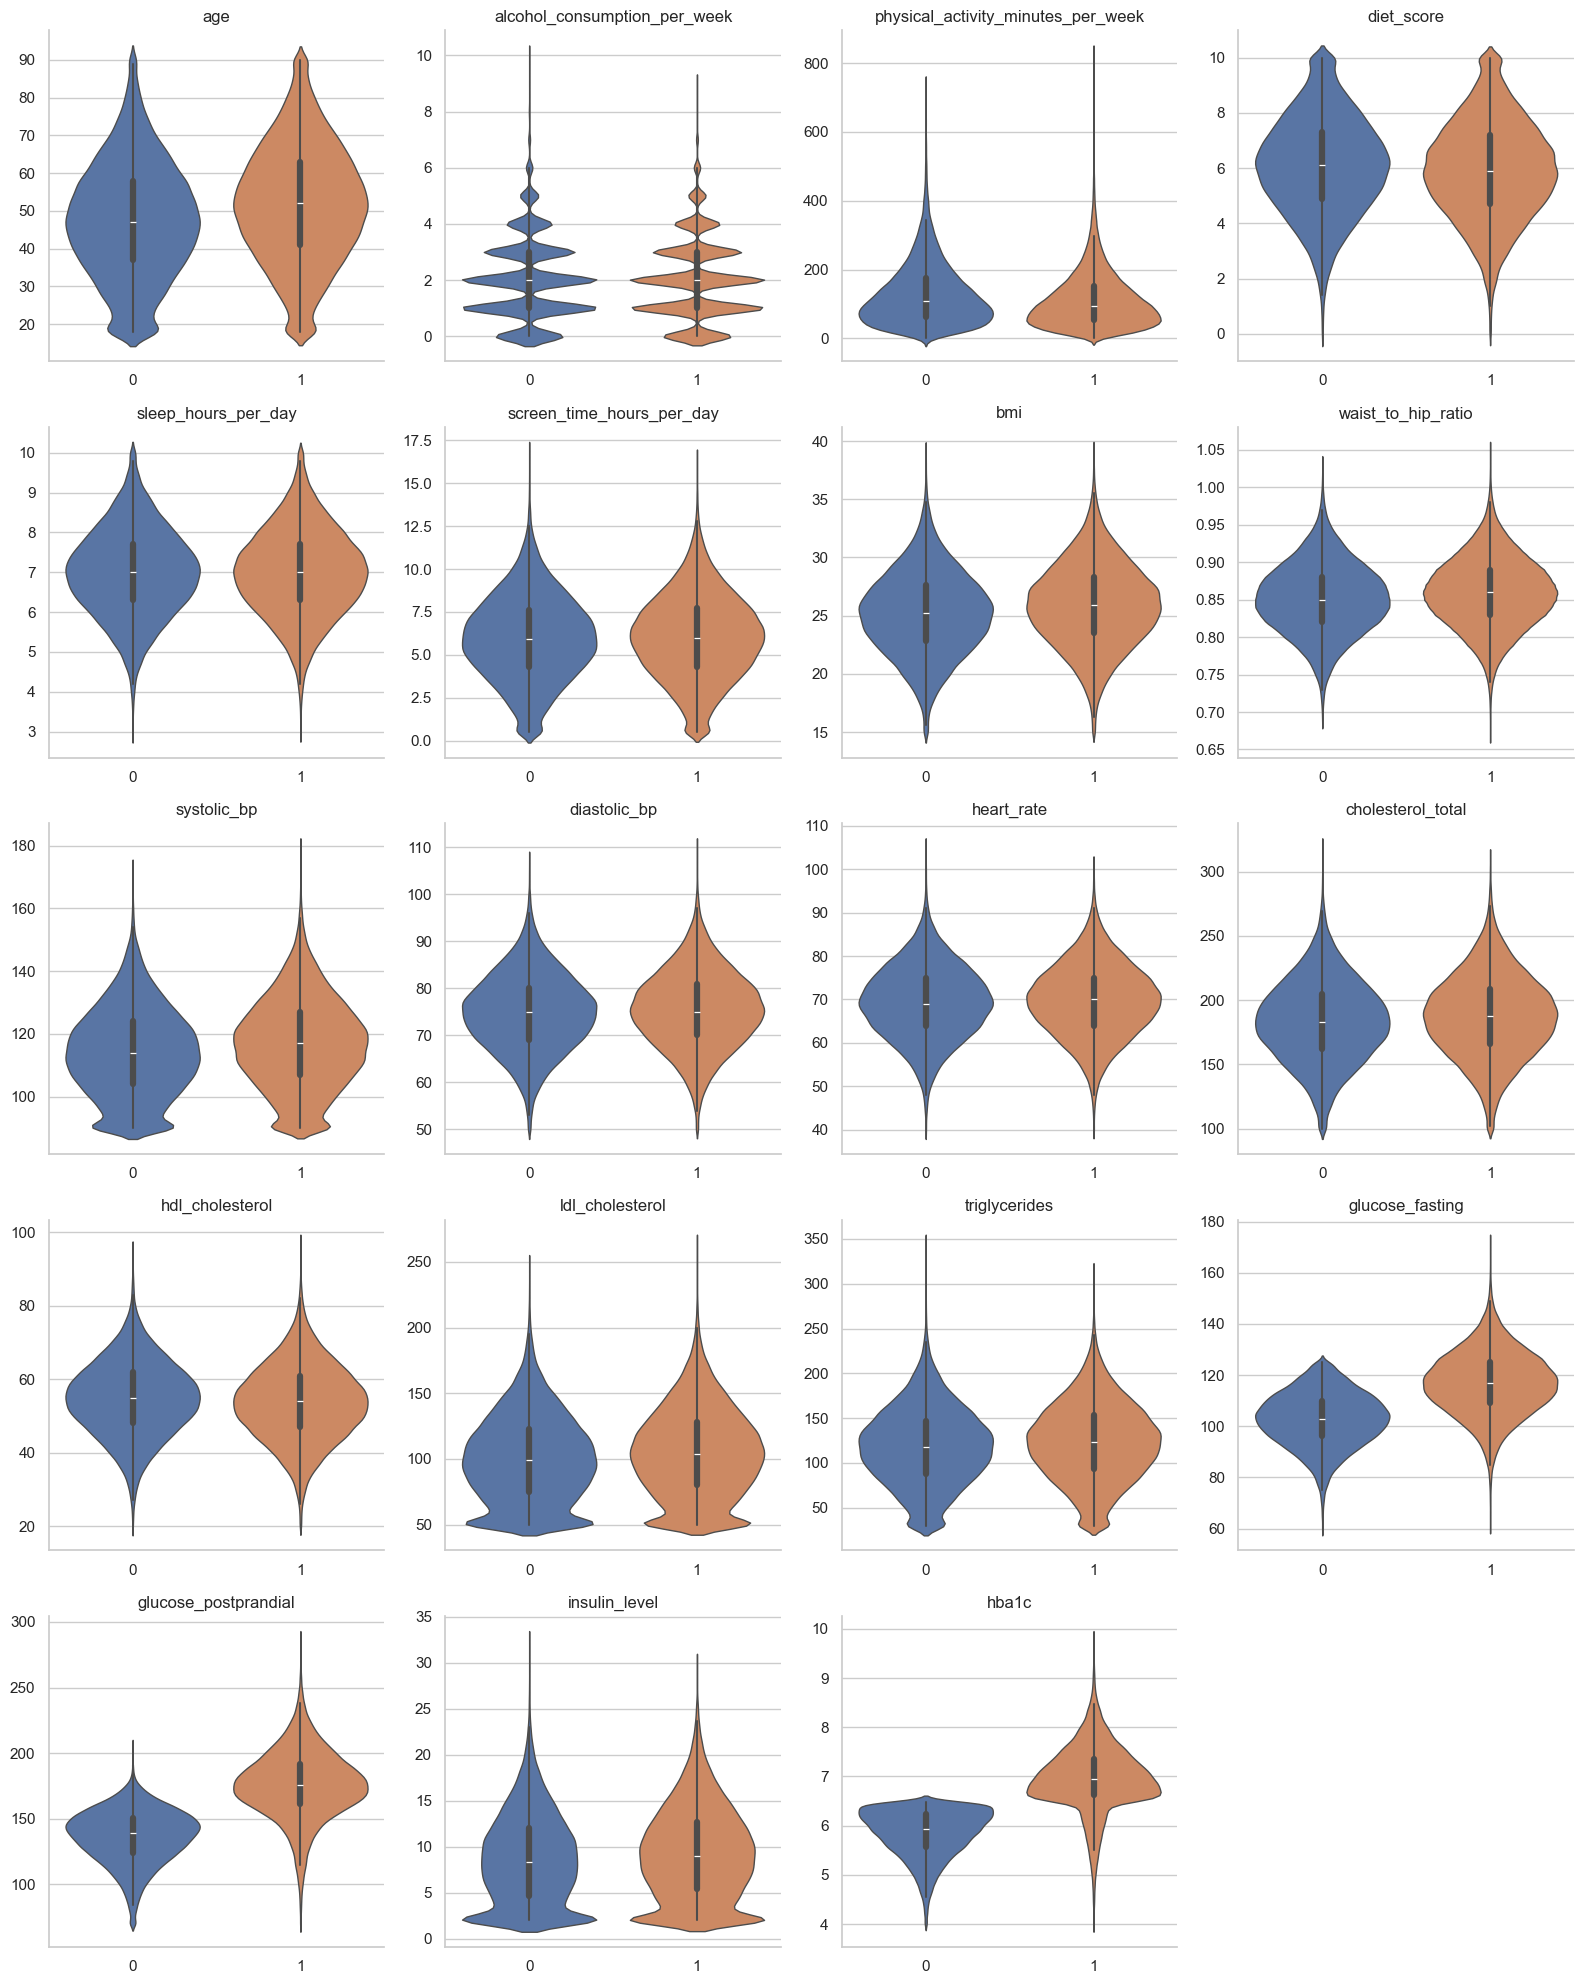

In [ ]:
# Violin plots: Numeric Features vs Target (TRAIN only)

numeric_cols = sch.NUMERIC_COLS
target = sch.TARGET_COL

n_features = len(numeric_cols)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.violinplot(
        data=train_base,
        x=target,
        y=col,
        hue=target,
        palette={0: "#4C72B0", 1: "#DD8452"},
        inner="box",
        linewidth=1,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Hide unused panels
for j in range(n_features, len(axes)):
    axes[j].axis("off")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "train_numeric_vs_target_violin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.9 Scatter plots comparison

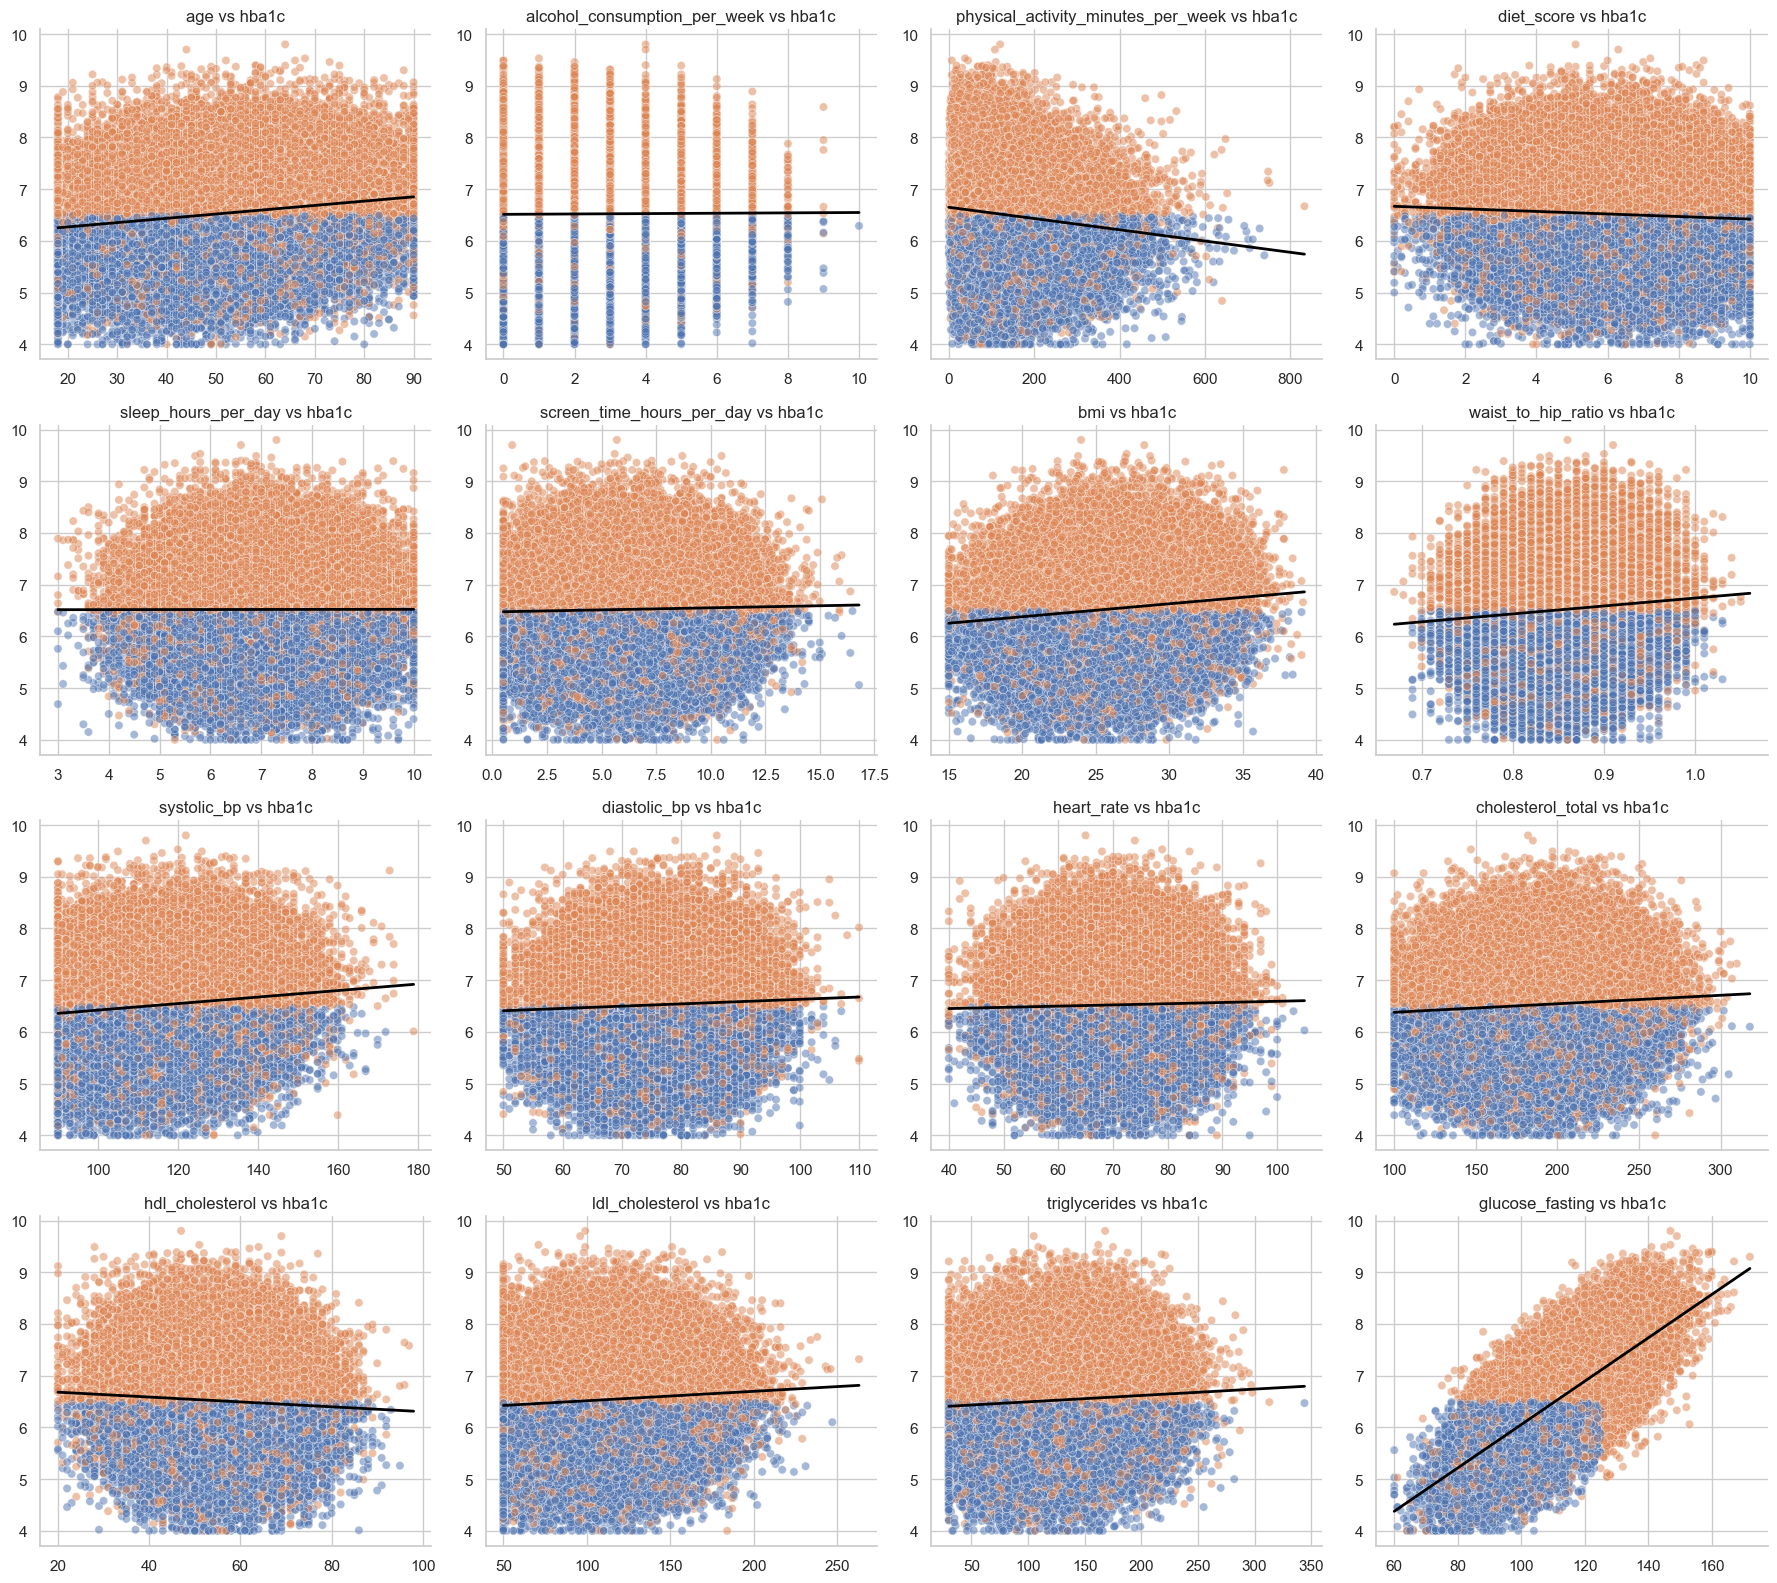

In [ ]:
focus_var = "hba1c"
features = [col for col in numeric_cols if col != focus_var][:16]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(features):

    ax = axes[i]

    # Scatter by class
    sns.scatterplot(
        data=train_base,
        x=col,
        y=focus_var,
        hue=target,
        palette=["#4C72B0", "#DD8452"],
        alpha=0.5,
        ax=ax,
        legend=False
    )

    # Fast linear regression line
    x = df[col].values
    y = df[focus_var].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept = np.polyfit(x[mask], y[mask], 1)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    ax.plot(x_line, y_line, color="black", linewidth=2)

    ax.set_title(f"{col} vs {focus_var}")
    ax.set_xlabel("")
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.savefig(
    FIG_DIR / "focused_scatter_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### EDA Summary

Exploratory analysis revealed clear physiological structure in the dataset. Strong collinearity was observed within feature families, particularly among body composition (BMI vs. waist-to-hip ratio), lipid measures (total cholesterol vs. HDL/LDL), and glycemic markers (fasting glucose, postprandial glucose, and HbA1c). To reduce redundancy and improve interpretability, representative variables were retained within each family.

HbA1c emerged as the dominant predictor of diagnosed diabetes, followed by BMI, triglycerides, insulin levels, and systolic blood pressure. Even when HbA1c was excluded from feature ranking, metabolic and cardiovascular variables continued to drive model importance, confirming structural robustness.

Categorical demographic variables showed comparatively weaker associations with diabetes, suggesting that physiological markers carry the primary predictive signal in this dataset.

Train and full distributions were nearly identical, indicating proper stratification and no sampling drift. After feature curation, multicollinearity was substantially reduced.

These findings directly inform the modeling stage by:
- Reducing redundant predictors,
- Preserving clinically interpretable structure,
- Improving model stability and generalizability.

---

## **4.** Curated Feature Set

This section applies the feature drops determined from training-set EDA and domain review.

The following variables were identified as redundant or strongly collinear within physiological families:
- `waist_to_hip_ratio` (redundant with BMI/body composition)
- `cholesterol_total` (redundant with HDL/LDL components)
- `glucose_fasting` (redundant with HbA1c and postprandial glucose)
- `glucose_postprandial` (redundant with HbA1c and fasting glucose)

These features are removed from both `train_base` and `test_base`.

The curated datasets are saved as pipeline checkpoints in `data/processed/curated/`.

In [ ]:
# CURATED DROP LIST
curation_drop_cols = [
    "waist_to_hip_ratio",
    "cholesterol_total",
    "glucose_fasting",
    "glucose_postprandial",
]

# Sanity checks
assert sch.TARGET_COL not in curation_drop_cols, "Target cannot be dropped."
assert all(
    col in train_base.columns for col in curation_drop_cols
), "One or more curated drop columns missing."
assert not any(
    col in sch.LEAKAGE_COLS for col in curation_drop_cols
), "Leakage columns should already be removed."

In [ ]:
# Apply curated drops
train_curated_full = pp.drop_columns(train_base, curation_drop_cols)
test_curated_full = pp.drop_columns(test_base, curation_drop_cols)

# Save curated datasets
io.save_processed_data(train_curated_full, PROC_CURATED_DIR / "train_curated_full.csv")
io.save_processed_data(test_curated_full, PROC_CURATED_DIR / "test_curated_full.csv")

# Save metadata
io.save_metadata_json(
    {
        "source_datasets": {
            "train": "splits/train_base.csv",
            "test": "splits/test_base.csv",
        },
        "target": sch.TARGET_COL,
        "leakage_cols_removed_pre_split": sch.LEAKAGE_COLS,
        "curation_drop_cols": curation_drop_cols,
        "n_dropped": int(len(curation_drop_cols)),
        "n_features_before": int(train_base.shape[1] - 1),
        "n_features_after": int(train_curated_full.shape[1] - 1),
        "columns_after": [c for c in train_curated_full.columns if c != sch.TARGET_COL],
        "notes": "Redundant physiological measures removed based on training-set EDA and domain reasoning.",
    },
    PROC_CURATED_DIR / "curation.json",
)

if VERBOSE:
    print("Curated datasets saved:")
    print("  train_curated_full:", train_curated_full.shape)
    print("  test_curated_full: ", test_curated_full.shape)

Curated datasets saved:
  train_curated_full: (80000, 25)
  test_curated_full:  (20000, 25)


### Summary

- 4 physiologically redundant variables were removed:
  - `waist_to_hip_ratio`
  - `cholesterol_total`
  - `glucose_fasting`
  - `glucose_postprandial`

- The curated training set now contains **24 predictors**.

- Curated datasets have been saved to `data/processed/curated/`.

---

## **5.** Random Forest Feature Screening (Train Curated)

This section fits a Random Forest classifier on the **curated training set** (`train_curated_full`) for **feature screening only**.

- The Random Forest is trained on **training data only** to avoid test-set leakage.
- **Feature importance rankings** are reported to guide construction of a reduced predictor set.
- Because categorical variables are one-hot encoded, an **aggregated importance view** (importance summed across levels) is reported for interpretability.

Outputs are saved to:
- `results/tables/` (importance tables)
- `results/figures/` (importance plot)

### **5.1** RF Screening - Including `HbA1c`

This screening pass includes `HbA1c`. Because `HbA1c` is a diagnostic biomarker closely tied to diabetes diagnosis, it is expected to dominate importance rankings. These results are retained to document that dominance and to motivate a secondary screening pass that excludes `HbA1c`.

In [ ]:
# Load curated train/test datasets (Created in Section 4)

train_curated_full = io.load_processed_data(PROC_CURATED_DIR / "train_curated_full.csv")
test_curated_full = io.load_processed_data(PROC_CURATED_DIR / "test_curated_full.csv")

if VERBOSE:
    print("Loaded curated datasets:")
    print("  train_curated_full:", train_curated_full.shape)
    print("  test_curated_full: ", test_curated_full.shape)
    assert sch.TARGET_COL in train_curated_full.columns
    assert sch.TARGET_COL in test_curated_full.columns

Loaded curated datasets:
  train_curated_full: (80000, 25)
  test_curated_full:  (20000, 25)


In [ ]:
cat_cols = [c for c in sch.CATEGORICAL_COLS if c in train_curated_full.columns]

num_cols = [
    c
    for c in (sch.NUMERIC_COLS + [c for c in sch.BINARY_COLS if c != sch.TARGET_COL])
    if c in train_curated_full.columns
]

rf_model, rf_importance = mdl.fit_rf_feature_screening(
    train_curated_full,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_cols,
    numeric_cols=num_cols,
    random_state=SEED,
    n_estimators=500,
)

In [ ]:
# Aggregate Importances across One-Hot Levels
rf_importance_agg = mdl.aggregate_importance_by_feature(
    rf_importance,
    categorical_cols=sch.CATEGORICAL_COLS,
)

if VERBOSE:
    display(rf_importance_agg)

,feature,importance
0,hba1c,0.632149
1,physical_activity_minutes_per_week,0.025835
2,age,0.024671
3,bmi,0.023008
4,triglycerides,0.021647
5,insulin_level,0.021496
6,screen_time_hours_per_day,0.020732
7,ldl_cholesterol,0.020543
8,diet_score,0.020395
9,systolic_bp,0.020072


In [ ]:
# Save Aggregated Importance Table (CSV + LaTeX)
io.save_table_csv(
    rf_importance_agg,
    TAB_DIR / "rf_train_curated_feature_importance_aggregated.csv",
    save=SAVE_TABLES,
)

io.save_table_tex(
    rf_importance_agg,
    TAB_DIR / "rf_train_curated_feature_importance_aggregated.tex",
    caption="Random Forest Feature Importances (Curated Train Datset; Aggregated across Categorical Levels).",
    label="tab:rf_importance_agg",
    escape_underscore_cols=("feature",),
    save=SAVE_TABLES,
);

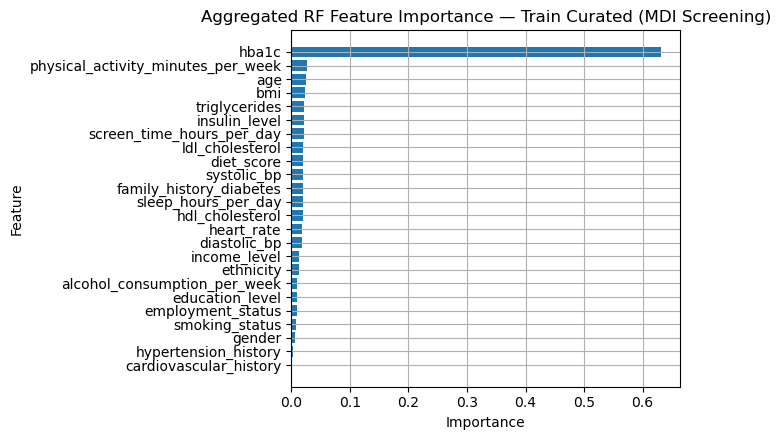

In [ ]:
# Plot Aggregated Importance (all Predictors)
top_n_all = len(rf_importance_agg)

fig, ax = viz.plot_feature_importance_bar(
    rf_importance_agg,
    top_n=top_n_all,
    title="Aggregated RF Feature Importance — Train Curated (MDI Screening)",
)

viz.finalize_fig(
    fig,
    save_path=(
        (FIG_DIR / "rf_train_curated_feature_importance_aggregated.png")
        if SAVE_FIGS
        else None
    ),
    show=VERBOSE,
)

**Finding (Including `HbA1c`):**  
`HbA1c` accounts for a majority of total Random Forest importance. This is consistent with its clinical role as a diagnostic biomarker for diabetes.

Because Mean Decrease in Impurity (MDI) importance is relative, the dominance of `HbA1c` compresses the importance of remaining predictors, making it difficult to distinguish structural differences among them.  To construct a reduced model that still includes `HbA1c`, the remaining predictors are analyzed separately by renormalizing their importances.

### **5.2** Reduced Model Construction via Renormalized Importance

To determine a reduced predictor set while retaining `HbA1c`, the importance values of all non-`HbA1c` predictors are renormalized to sum to one. This isolates the relative contribution of the remaining predictors and allows cumulative importance thresholds to be evaluated without distortion from the dominant biomarker.

In [ ]:
# RENORMALIZE NON-HbA1c IMPORTANCES

# Remove HbA1c Row - Treat HbA1c as Always-Included to Analyze the Rest
rf_non = rf_importance_agg.loc[rf_importance_agg["feature"] != "hba1c"].copy()
rf_non = rf_non.sort_values("importance", ascending=False).reset_index(drop=True)

# Renormalize Remaining Importances to Sum to 1
total_non = rf_non["importance"].sum()
rf_non["importance_renorm"] = rf_non["importance"] / total_non

# Cumulative Importance on the Renormalized Values
rf_non["cumulative_renorm"] = rf_non["importance_renorm"].cumsum()

In [ ]:
# Display table
if VERBOSE:
    display(rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]])

# Save table
io.save_table_csv(
    rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]],
    TAB_DIR / "rf_train_curated_importance_non_hba1c_renormalized.csv",
    save=SAVE_TABLES,
)

io.save_table_tex(
    rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]],
    TAB_DIR / "rf_train_curated_importance_non_hba1c_renormalized.tex",
    caption="Renormalized Random Forest Feature Importances (Non-HbA1c Predictors Only). Cumulative importance is computed after renormalizing to sum to one.",
    label="tab:rf_importance_renorm_non_hba1c",
    escape_underscore_cols=("feature",),
    save=SAVE_TABLES,
)

,feature,importance,importance_renorm,cumulative_renorm
0,physical_activity_minutes_per_week,0.025835,0.070231,0.070231
1,age,0.024671,0.067067,0.137298
2,bmi,0.023008,0.062547,0.199845
3,triglycerides,0.021647,0.058848,0.258693
4,insulin_level,0.021496,0.058436,0.317129
5,screen_time_hours_per_day,0.020732,0.056359,0.373488
6,ldl_cholesterol,0.020543,0.055846,0.429334
7,diet_score,0.020395,0.055443,0.484777
8,systolic_bp,0.020072,0.054565,0.539342
9,family_history_diabetes,0.019602,0.053289,0.592631


WindowsPath('C:/Users/etoob/OneDrive/Documents/School/STATS/STAT587_DS1/Project/diabetes-prediction-ds1/results/tables/rf_train_curated_importance_non_hba1c_renormalized.tex')

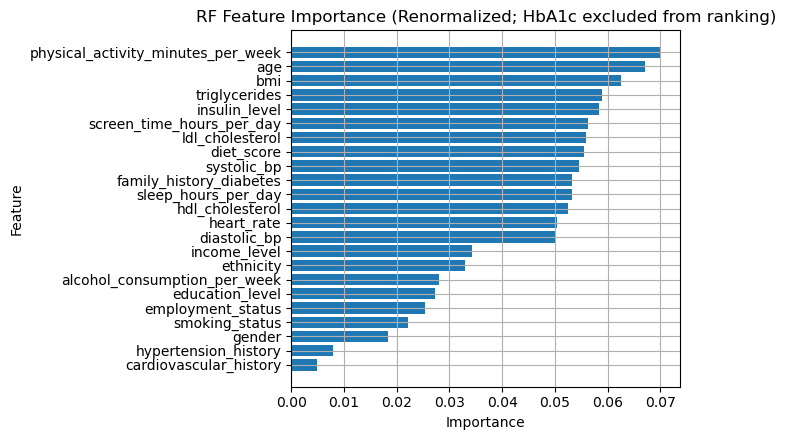

In [ ]:
# Plot Renormalized Importance Barplot (all non-HbA1c Predictors)
rf_non_plot = rf_non[["feature", "importance_renorm"]].rename(
    columns={"importance_renorm": "importance"}
)

fig, ax = viz.plot_feature_importance_bar(
    rf_non_plot,
    top_n=len(rf_non_plot),
    title="RF Feature Importance (Renormalized; HbA1c excluded from ranking)",
)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "rf_importance_renorm_non_hba1c.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

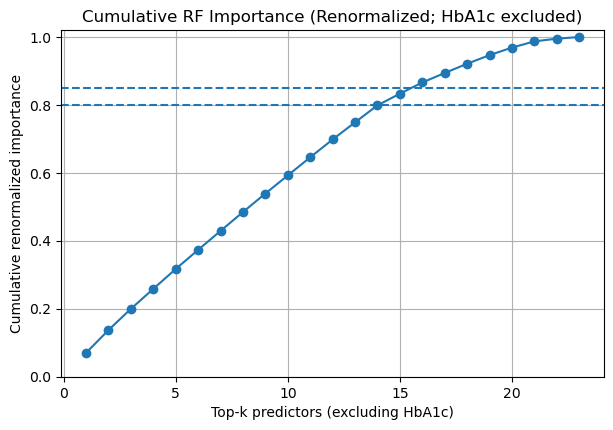

In [ ]:
# Plot Cumulative Curve (Renormalized)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(range(1, len(rf_non) + 1), rf_non["cumulative_renorm"].values, marker="o")
ax.axhline(0.80, linestyle="--")
ax.axhline(0.85, linestyle="--")
ax.set_xlabel("Top-k predictors (excluding HbA1c)")
ax.set_ylabel("Cumulative renormalized importance")
ax.set_title("Cumulative RF Importance (Renormalized; HbA1c excluded)")
ax.set_ylim(0, 1.02)
ax.grid(True)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "rf_cumulative_renorm_non_hba1c.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

**Reduced Model Selection:**  

The cumulative renormalized importance reaches approximately 80\% at the inclusion of `diastolic_bp` (14 non-`HbA1c` predictors). This threshold captures a substantial majority of the relative importance among non-diagnostic predictors while reducing dimensionality.

In addition to the 80\% cumulative threshold, the importance profile exhibits a noticeable drop in magnitude immediately after `diastolic_bp`. Predictors ranked below this point contribute substantially smaller incremental importance values, indicating diminishing marginal contribution beyond this cutoff.

The reduced model is therefore defined as:

- `HbA1c`, plus  
- The top 14 non-`HbA1c` predictors ranked by renormalized importance.

This results in a 15-predictor model for structural comparison against the full model.

### **5.3** Save the Reduced Datasets

Using the selected predictor set defined above, reduced training and test datasets are constructed. The same predictors are retained in both datasets to ensure consistency in downstream modeling comparisons.

In [ ]:
# Construct Reduced Predictor List
top_k_non_hba1c = 14
selected_non_hba1c = rf_non["feature"].iloc[:top_k_non_hba1c].tolist()

reduced_features = ["hba1c"] + selected_non_hba1c

# Ensure target included
reduced_cols = reduced_features + [sch.TARGET_COL]

train_reduced = train_curated_full[reduced_cols].copy()
test_reduced = test_curated_full[reduced_cols].copy()

# Save reduced datasets
io.save_processed_data(
    train_reduced,
    PROC_REDUCED_DIR / "train_reduced_structural.csv",
)

io.save_processed_data(
    test_reduced,
    PROC_REDUCED_DIR / "test_reduced_structural.csv",
)

if VERBOSE:
    print("Reduced model predictors:")
    print(reduced_features)
    print("Train reduced shape:", train_reduced.shape)

Reduced model predictors:
['hba1c', 'physical_activity_minutes_per_week', 'age', 'bmi', 'triglycerides', 'insulin_level', 'screen_time_hours_per_day', 'ldl_cholesterol', 'diet_score', 'systolic_bp', 'family_history_diabetes', 'sleep_hours_per_day', 'hdl_cholesterol', 'heart_rate', 'diastolic_bp']
Train reduced shape: (80000, 16)


### Section Summary

- Random Forest screening confirms `HbA1c` as the dominant predictor.
- To construct a reduced model without distorting importance rankings, non-`HbA1c` predictors were renormalized.
- The reduced model retains `HbA1c` and the top 14 non-`HbA1c` predictors, capturing approximately 80\% of renormalized cumulative importance.
- Both full and reduced datasets have been saved for subsequent logistic regression comparison.

---
---
---
---
---

---

## **5.** Evaluation Framework  - Splitting train/test and any checks; scaling

Evaluate models using consistent metrics appropriate for a ~60/40 class split:
- ROC-AUC (primary)
- Accuracy
- Confusion matrix (and derived metrics such as precision/recall/F1 as needed)
- Dice (IoU)/F1

All models use the same train/test split (seeded) and the same preprocessing pipeline where applicable.

In [ ]:
# Evaluation helpers / results container
# TODO: Implement standardized evaluation functions in src.metrics

results = []  # list of dicts, later converted to a DataFrame

"""
Possible addition to src.metrics (maybe kept here?):

def add_result(model_name: str, metrics: dict):
    row = {"model": model_name, **metrics}
    results.append(row)
"""

---

## **5.** Method 1 &ndash; Logistic Regression + Regularized

Logistic regression provides an interpretable baseline. Ridge and LASSO regularization are included to:
- address correlated predictors / multicollinearity
- compare stability of coefficient-based variable importance

In [ ]:
# Logistic Regression (baseline + Ridge + LASSO)
# TODO: Implement in src.modeling, return metrics dict and model objects as needed

# Example intended flow:
# metrics_lr, model_lr = src.modeling.fit_logistic_regression(X_train, y_train, X_test, y_test, seed=SEED)
# add_result("Logistic Regression", metrics_lr)

# metrics_ridge, model_ridge = src.modeling.fit_logistic_ridge(...)
# add_result("Logistic Regression (Ridge)", metrics_ridge)

# metrics_lasso, model_lasso = src.modeling.fit_logistic_lasso(...)
# add_result("Logistic Regression (LASSO)", metrics_lasso)

pass

---

## **6.** Method 2 &ndash; Random Forest

Random forests capture nonlinear relationships and interactions and provide feature importance measures for comparison with logistic regression.

In [ ]:
# Random Forest
# TODO: Implement in src.modeling

# Example intended flow:
# metrics_rf, model_rf = src.modeling.fit_random_forest(X_train, y_train, X_test, y_test, seed=SEED)
# add_result("Random Forest", metrics_rf)

pass

---

## **7.** Method 3 &ndash; Gradient Boosting (XGBoost)

Gradient boosting is evaluated as a high-capacity ensemble method. Compare its performance and trade-offs to random forests and logistic regression.

In [ ]:
# XGBoost
# TODO: Implement in src.modeling (requires xgboost package)

# Example intended flow:
# metrics_xgb, model_xgb = src.modeling.fit_xgboost(X_train, y_train, X_test, y_test, seed=SEED)
# add_result("XGBoost", metrics_xgb)

pass

---

## **8.** Method 4 (Optional) &ndash; Shallow Neural Network (MLP)

In [ ]:
# Optional MLP
# TODO: Implement if included

pass

---

## **9.** Model Comparison

Results compiled across all methods into:
- a final comparison table
- performance visualizations (e.g., ROC curves, metric bar charts)
- interpretability comparisons (coefficients vs feature importances)

Tables are saved to `results/tables/` and figures to `results/figures/`.

In [ ]:
# Model comparison
results_df = pd.DataFrame(results)
results_df

In [ ]:
# Save comparison table (CSV). 
# Add LaTeX export later - Utilize src files for functionality.
"""
OUT_CSV = TAB_DIR / "model_comparison.csv"
results_df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
"""

---

## **10.** Discussion and Conclusions

Summarize:
- which model performed best and why
- most influential predictors (and whether consistent across models)
- interpretability vs performance trade-offs
- limitations (synthetic data, documentation mismatch)
- next steps / improvements

---

## **11.** Minimal Reproducibility Notes

To reproduce:
1. Ensure raw data is present in `data/raw/`
2. Run this notebook top-to-bottom

Notes:
- Seed: `SEED = 587`
- Generated outputs: `data/processed/`, `results/figures/`, `results/tables/`
- Full environment/setup instructions will be documented in `README.md`